# Meronym & Holonym statistics — Open English WordNet 2025

Deeper insight into the part/whole structure extracted by
`extract_meronym_holonym.ipynb`. All figures are computed **directly from the
`oewn:2025` lexicon** (so counts are exact, not affected by the repetition in the
flattened text file) using the same relation set and cycle-guarded traversal as
the extractor.

Sections:
1. **Coverage** — how much of WordNet participates in part/whole relations
2. **Subtype breakdown** — part / member / substance / location / portion
3. **Degree distributions** — how many parts a whole has, how many wholes a part belongs to
4. **Hubs** — the synsets with the most parts / most wholes
5. **Tree shape** — depth and size of the recursive trees written to the text file
6. **Key findings** — an auto-generated summary

> Requires `pandas`, `matplotlib`, `numpy` in the venv:
> `../.venv/bin/python -m pip install pandas matplotlib numpy`


In [1]:
import os
import sys
from collections import Counter

import wn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the same lexicon / data dir the extractor used ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
wn.config.data_directory = os.path.join(REPO_ROOT, "data", "wn2025")
LEXICON = "oewn:2025"
en = wn.Wordnet(LEXICON)

OUT_DIR = "stats_output"          # charts + CSVs are saved here
os.makedirs(OUT_DIR, exist_ok=True)

# ---- Chart styling: validated data-viz palette (light surface) ----
SURFACE, INK, INK2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")
MERO_C, HOLO_C = "#2a78d6", "#eb6834"          # blue / orange: max separation
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 11,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "figure.dpi": 110,
})

def style_ax(ax, ygrid=True):
    """Recessive grid on one axis only, no tick marks."""
    ax.xaxis.grid(not ygrid)
    ax.yaxis.grid(ygrid)
    ax.tick_params(length=0)

def title(ax, text):
    ax.set_title(text, color=INK, loc="left", fontsize=12.5, fontweight="bold", pad=10)

print("Loaded", LEXICON, "-", f"{len(en.synsets()):,}", "synsets")


Loaded oewn:2025 - 107,519 synsets


In [2]:
# ---- Build the relation model once (edges, degrees, adjacency, POS) ----
MERONYM_RELATIONS = ["mero_part", "mero_member", "mero_substance",
                     "mero_location", "mero_portion"]
HOLONYM_RELATIONS = ["holo_part", "holo_member", "holo_substance",
                     "holo_location", "holo_portion"]

all_synsets = en.synsets()
label, pos_of = {}, {}
mero_adj, holo_adj = {}, {}         # id -> [child ids]  (deduped across subtypes)
mero_deg, holo_deg = {}, {}         # id -> number of direct meronyms / holonyms
mero_sub, holo_sub = Counter(), Counter()   # subtype -> edge count

def collect(ss, relations, sub_counter):
    children, seen = [], set()
    for rel in relations:
        targets = ss.get_related(rel)
        sub_counter[rel] += len(targets)
        for t in targets:
            if t.id not in seen:
                seen.add(t.id)
                children.append(t.id)
    return children

for ss in all_synsets:
    label[ss.id] = ", ".join(ss.lemmas())
    pos_of[ss.id] = ss.pos
    m = collect(ss, MERONYM_RELATIONS, mero_sub)
    if m:
        mero_adj[ss.id] = m
        mero_deg[ss.id] = len(m)
    h = collect(ss, HOLONYM_RELATIONS, holo_sub)
    if h:
        holo_adj[ss.id] = h
        holo_deg[ss.id] = len(h)

print(f"wholes (>=1 meronym): {len(mero_adj):,}")
print(f"parts  (>=1 holonym): {len(holo_adj):,}")


wholes (>=1 meronym): 4,099
parts  (>=1 holonym): 5,954


## 1. Coverage

How much of WordNet takes part in part/whole relations, and confirmation that meronymy is (as expected) a noun-only relation.

In [3]:
total = len(all_synsets)
coverage = pd.DataFrame({
    "metric": ["Total synsets",
               "Wholes  (>=1 meronym)",
               "Parts   (>=1 holonym)",
               "Meronym edges",
               "Holonym edges"],
    "value":  [total, len(mero_adj), len(holo_adj),
               sum(mero_deg.values()), sum(holo_deg.values())],
})
coverage["% of synsets"] = (coverage["value"] / total * 100).round(2)
coverage.to_csv(os.path.join(OUT_DIR, "coverage.csv"), index=False)

whole_pos = Counter(pos_of[i] for i in mero_adj)
part_pos  = Counter(pos_of[i] for i in holo_adj)
print("POS of wholes:", dict(whole_pos))
print("POS of parts :", dict(part_pos))
coverage


POS of wholes: {'n': 4099}
POS of parts : {'n': 5954}


,metric,value,% of synsets
0,Total synsets,107519,100.00
1,Wholes (>=1 meronym),4099,3.81
2,Parts (>=1 holonym),5954,5.54
3,Meronym edges,6935,6.45
4,Holonym edges,6935,6.45


## 2. Subtype breakdown

Meronymy splits into *part / member / substance / location / portion*. Because holonymy is the inverse of meronymy, each holonym subtype count should mirror its meronym counterpart — a useful integrity check.

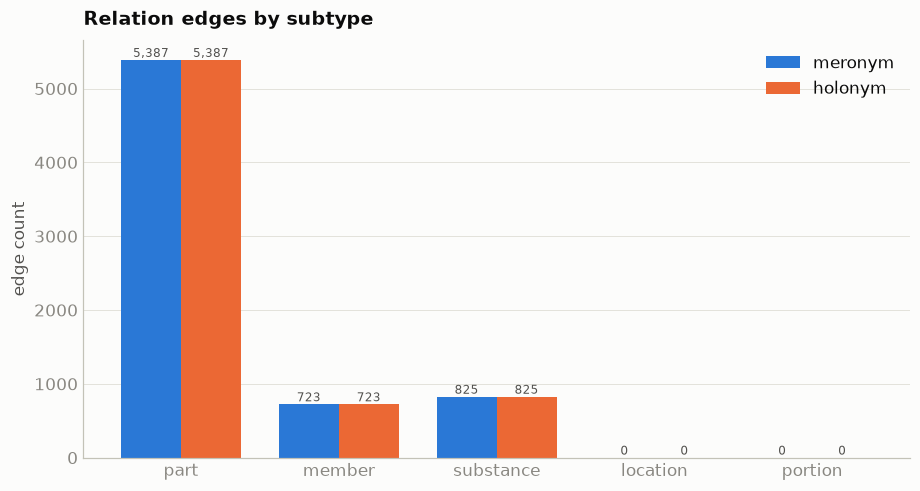

,subtype,meronym,holonym
0,part,5387,5387
1,member,723,723
2,substance,825,825
3,location,0,0
4,portion,0,0


In [4]:
subs = ["part", "member", "substance", "location", "portion"]
mero_vals = [mero_sub[f"mero_{s}"] for s in subs]
holo_vals = [holo_sub[f"holo_{s}"] for s in subs]

subtype_df = pd.DataFrame({"subtype": subs, "meronym": mero_vals, "holonym": holo_vals})
subtype_df.to_csv(os.path.join(OUT_DIR, "subtype_counts.csv"), index=False)

x, w = np.arange(len(subs)), 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = [ax.bar(x - w/2, mero_vals, w, label="meronym", color=MERO_C),
        ax.bar(x + w/2, holo_vals, w, label="holonym", color=HOLO_C)]
for group in bars:
    for r in group:
        ax.annotate(f"{int(r.get_height()):,}",
                    (r.get_x() + r.get_width()/2, r.get_height()),
                    ha="center", va="bottom", fontsize=8, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(subs)
ax.set_ylabel("edge count")
title(ax, "Relation edges by subtype")
ax.legend(frameon=False, loc="upper right")
style_ax(ax)
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "edges_by_subtype.png"), bbox_inches="tight")
plt.show()
subtype_df


## 3. Degree distributions

**Meronyms per whole** = how many parts a synset is decomposed into. **Holonyms per part** = how many different wholes a synset belongs to. Distributions are heavy-tailed, so the y-axis is log-scaled.

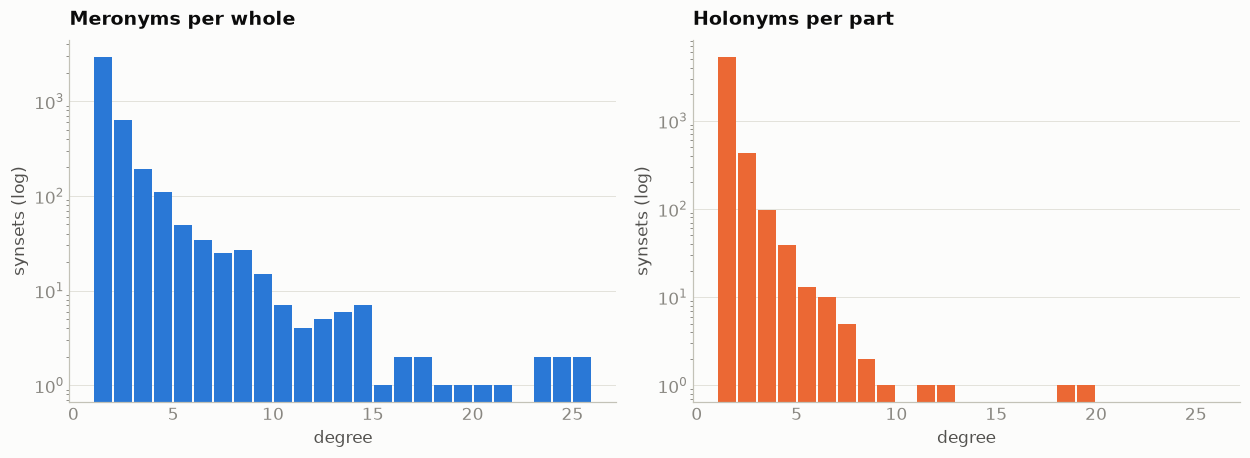

,meronyms per whole,holonyms per part
count,4099.00,5954.00
mean,1.69,1.16
median,1.00,1.00
p90,3.00,2.00
p99,10.00,4.00
max,31.00,28.00


In [5]:
def describe(vals, name):
    a = np.array(vals)
    return pd.Series({"count": len(a), "mean": round(a.mean(), 2),
                      "median": int(np.median(a)), "p90": int(np.percentile(a, 90)),
                      "p99": int(np.percentile(a, 99)), "max": int(a.max())}, name=name)

deg_summary = pd.concat([describe(list(mero_deg.values()), "meronyms per whole"),
                         describe(list(holo_deg.values()), "holonyms per part")], axis=1)
deg_summary.to_csv(os.path.join(OUT_DIR, "degree_summary.csv"))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for ax, vals, color, ttl in [
        (axes[0], list(mero_deg.values()), MERO_C, "Meronyms per whole"),
        (axes[1], list(holo_deg.values()), HOLO_C, "Holonyms per part")]:
    top = min(max(vals), 25)
    ax.hist(vals, bins=range(1, top + 2), color=color, rwidth=0.9)
    title(ax, ttl)
    ax.set_xlabel("degree"); ax.set_ylabel("synsets (log)"); ax.set_yscale("log")
    style_ax(ax)
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "degree_distributions.png"), bbox_inches="tight")
plt.show()
deg_summary


## 4. Hubs — the most connected synsets

Synsets with the most parts (top meronym hubs) and those belonging to the most wholes (top holonym hubs).

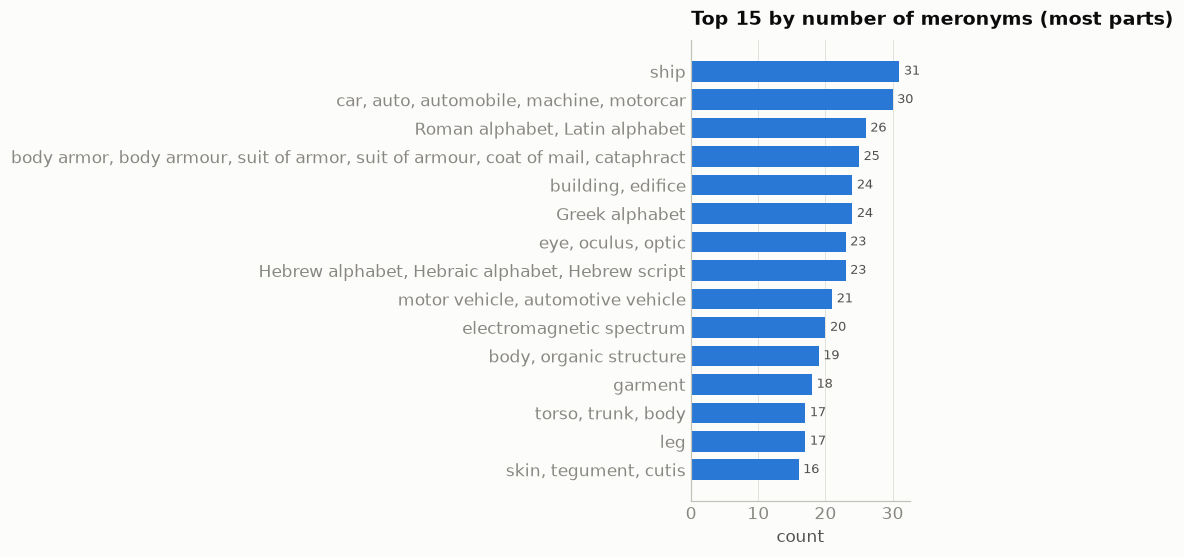

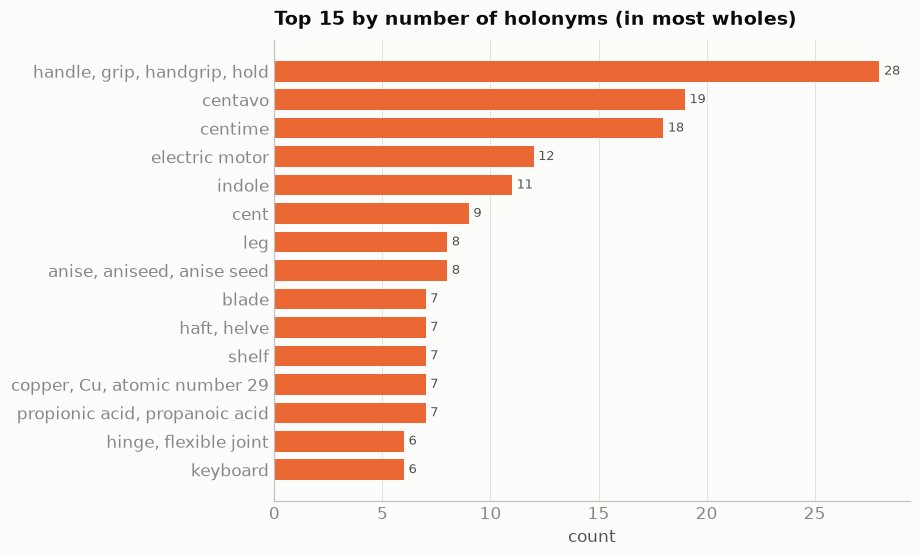

,synset,id,count
0,ship,oewn-04201332-n,31
1,"car, auto, automobile, machine, motorcar",oewn-02961779-n,30
2,"Roman alphabet, Latin alphabet",oewn-06509863-n,26
3,"body armor, body armour, suit of armor, suit o...",oewn-02865388-n,25
4,"building, edifice",oewn-02916498-n,24
5,Greek alphabet,oewn-06511235-n,24
6,"eye, oculus, optic",oewn-05318579-n,23
7,"Hebrew alphabet, Hebraic alphabet, Hebrew script",oewn-06510560-n,23
8,"motor vehicle, automotive vehicle",oewn-03796768-n,21
9,electromagnetic spectrum,oewn-11471859-n,20


,synset,id,count
0,"handle, grip, handgrip, hold",oewn-03491080-n,28
1,centavo,oewn-13687361-n,19
2,centime,oewn-13688070-n,18
3,electric motor,oewn-03277972-n,12
4,indole,oewn-92463112-n,11
5,cent,oewn-13686626-n,9
6,leg,oewn-03660152-n,8
7,"anise, aniseed, anise seed",oewn-07842629-n,8
8,blade,oewn-02851454-n,7
9,"haft, helve",oewn-03480019-n,7


In [6]:
def top_df(deg, n=15):
    items = sorted(deg.items(), key=lambda kv: -kv[1])[:n]
    return pd.DataFrame([{"synset": label[i], "id": i, "count": d} for i, d in items])

top_mero, top_holo = top_df(mero_deg), top_df(holo_deg)
top_mero.to_csv(os.path.join(OUT_DIR, "top_meronym_hubs.csv"), index=False)
top_holo.to_csv(os.path.join(OUT_DIR, "top_holonym_hubs.csv"), index=False)

def hbar(df, color, ttl, fname):
    d = df.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    ax.barh(range(len(d)), d["count"], color=color, height=0.72)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d["synset"])
    for i, v in enumerate(d["count"]):
        ax.annotate(f"{v}", (v, i), xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=INK2)
    title(ax, ttl)
    ax.set_xlabel("count")
    style_ax(ax, ygrid=False)
    fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, fname), bbox_inches="tight")
    plt.show()

hbar(top_mero, MERO_C, "Top 15 by number of meronyms (most parts)", "top_meronym_hubs.png")
hbar(top_holo, HOLO_C, "Top 15 by number of holonyms (in most wholes)", "top_holonym_hubs.png")
display(top_mero, top_holo)


## 5. Tree shape

Each root in the text file expands recursively (with a cycle guard along the current branch). Here we measure, per root, the **max depth** and the **line count** (= rows that root contributes to the file). `total lines` should match the section sizes reported by the extractor.

In [7]:
sys.setrecursionlimit(100000)

def tree_metrics(root, adj):
    """Max depth and cycle-guarded line count for one root (matches the .txt)."""
    stats = {"depth": 0, "lines": 0}
    def dfs(nid, depth, path):
        stats["lines"] += 1
        if depth > stats["depth"]:
            stats["depth"] = depth
        path.add(nid)
        for c in adj.get(nid, ()):
            if c not in path:
                dfs(c, depth + 1, path)
        path.discard(nid)
    dfs(root, 0, set())
    return stats["depth"], stats["lines"]

def metrics_frame(adj):
    rows = [(r, *tree_metrics(r, adj)) for r in adj]
    return pd.DataFrame(rows, columns=["id", "depth", "lines"])

mero_tree, holo_tree = metrics_frame(mero_adj), metrics_frame(holo_adj)

tree_summary = pd.DataFrame({
    "meronym trees": [len(mero_tree), int(mero_tree.depth.max()), round(mero_tree.depth.mean(), 2),
                      int(mero_tree.lines.max()), int(mero_tree.lines.sum())],
    "holonym trees": [len(holo_tree), int(holo_tree.depth.max()), round(holo_tree.depth.mean(), 2),
                      int(holo_tree.lines.max()), int(holo_tree.lines.sum())],
}, index=["root trees", "max depth", "mean depth", "max lines (biggest tree)", "total lines"])
tree_summary.to_csv(os.path.join(OUT_DIR, "tree_summary.csv"))
tree_summary


,meronym trees,holonym trees
root trees,4099.00,5954.00
max depth,14.00,14.00
mean depth,1.41,1.71
max lines (biggest tree),645.00,57.00
total lines,17026.00,18881.00


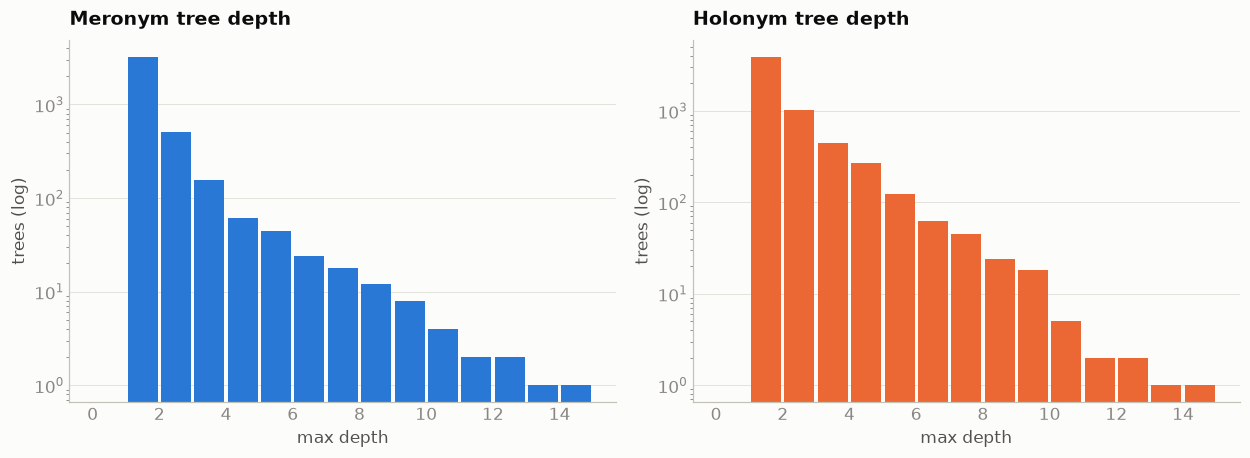

,synset,id,depth,lines
0,"body, organic structure",oewn-05223633-n,9,645
1,"animal, animate being, beast, brute, creature,...",oewn-00015568-n,8,242
2,"head, caput",oewn-05546258-n,7,239
3,"homo, man, human being, human",oewn-02474924-n,7,192
4,"face, human face",oewn-05608392-n,6,108
5,endoskeleton,oewn-05594096-n,6,106
6,"motor vehicle, automotive vehicle",oewn-03796768-n,4,105
7,"nervous system, systema nervosum",oewn-05469891-n,8,101
8,"building, edifice",oewn-02916498-n,6,92
9,"Gregorian calendar, New Style calendar",oewn-15199265-n,3,84


,synset,id,depth,lines
0,neuroepithelium,oewn-05248193-n,7,57
1,"shank, stem",oewn-04191138-n,3,37
2,"taste cell, gustatory cell",oewn-05312888-n,7,37
3,"tastebud, taste bud, gustatory organ",oewn-05312635-n,6,36
4,"handle, grip, handgrip, hold",oewn-03491080-n,2,30
5,"urethral orifice, external orifice",oewn-05520321-n,6,29
6,"selenium, Se, atomic number 34",oewn-14678354-n,6,24
7,armature,oewn-02741276-n,4,23
8,selenite,oewn-92463440-n,5,22
9,"vas deferens, ductus deferens",oewn-05533826-n,6,22


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for ax, df, color, ttl in [(axes[0], mero_tree, MERO_C, "Meronym tree depth"),
                           (axes[1], holo_tree, HOLO_C, "Holonym tree depth")]:
    vals = df["depth"]
    ax.hist(vals, bins=range(0, int(vals.max()) + 2), color=color, rwidth=0.9)
    title(ax, ttl)
    ax.set_xlabel("max depth"); ax.set_ylabel("trees (log)"); ax.set_yscale("log")
    style_ax(ax)
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR, "tree_depth.png"), bbox_inches="tight")
plt.show()

def biggest(df, n=15):
    d = df.sort_values("lines", ascending=False).head(n).copy()
    d["synset"] = d["id"].map(label)
    return d[["synset", "id", "depth", "lines"]].reset_index(drop=True)

big_mero, big_holo = biggest(mero_tree), biggest(holo_tree)
big_mero.to_csv(os.path.join(OUT_DIR, "biggest_meronym_trees.csv"), index=False)
big_holo.to_csv(os.path.join(OUT_DIR, "biggest_holonym_trees.csv"), index=False)
display(big_mero, big_holo)


## 6. Key findings (auto-generated)

In [9]:
pct = lambda a, b: f"{a / b * 100:.1f}%"
lines = [
    f"- WordNet 2025 has {total:,} synsets; {len(mero_adj):,} ({pct(len(mero_adj), total)}) "
    f"have at least one part (meronym) and {len(holo_adj):,} ({pct(len(holo_adj), total)}) "
    f"are part of some whole (holonym).",
    f"- Every participating synset is a noun: {set(whole_pos) | set(part_pos)}.",
    f"- 'part' dominates: {mero_sub['mero_part']:,} of {sum(mero_vals):,} meronym edges "
    f"({pct(mero_sub['mero_part'], sum(mero_vals))}); "
    f"member {mero_sub['mero_member']:,}, substance {mero_sub['mero_substance']:,}, "
    f"location {mero_sub['mero_location']:,}, portion {mero_sub['mero_portion']:,}.",
    f"- Meronym/holonym edge totals {'match' if sum(mero_deg.values()) == sum(holo_deg.values()) else 'differ'}"
    f" ({sum(mero_deg.values()):,} vs {sum(holo_deg.values()):,}) — expected for inverse relations.",
    f"- A whole has {np.mean(list(mero_deg.values())):.1f} parts on average "
    f"(max {max(mero_deg.values())}: '{label[max(mero_deg, key=mero_deg.get)]}'); "
    f"a part belongs to {np.mean(list(holo_deg.values())):.1f} wholes on average "
    f"(max {max(holo_deg.values())}: '{label[max(holo_deg, key=holo_deg.get)]}').",
    f"- Deepest meronym tree: {mero_tree.depth.max()} levels; "
    f"largest expands to {mero_tree.lines.max():,} rows "
    f"('{label[mero_tree.loc[mero_tree.lines.idxmax(), 'id']]}').",
    f"- Charts and CSVs written to ./{OUT_DIR}/",
]
print("\n".join(lines))


- WordNet 2025 has 107,519 synsets; 4,099 (3.8%) have at least one part (meronym) and 5,954 (5.5%) are part of some whole (holonym).
- Every participating synset is a noun: {'n'}.
- 'part' dominates: 5,387 of 6,935 meronym edges (77.7%); member 723, substance 825, location 0, portion 0.
- Meronym/holonym edge totals match (6,935 vs 6,935) — expected for inverse relations.
- A whole has 1.7 parts on average (max 31: 'ship'); a part belongs to 1.2 wholes on average (max 28: 'handle, grip, handgrip, hold').
- Deepest meronym tree: 14 levels; largest expands to 645 rows ('body, organic structure').
- Charts and CSVs written to ./stats_output/
